In [31]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8")
plt.rcParams.update({
    "font.family": "IBM Plex Sans",
    "axes.facecolor": "#FFFFFF",
    "axes.grid": True,
    "axes.grid.which": "major",
    "axes.grid.axis": "both",
    "axes.spines.bottom": True,
    "axes.spines.left": True,
    "axes.spines.right": True,
    "axes.spines.top": True,
    "axes.labelsize": 14,
    "grid.color": "#BBBBBB",
    "grid.linestyle": "--",
    "grid.linewidth": .5,
    "figure.frameon": True,
    "legend.fontsize": 11
})

In [3]:
SCENARIOS = ["lower_bound", "upper_bound", "join_first", "union_first"]
N_ENTRIES = ["1M", "10M", "50M", "100M"]

n_entries2numeric = {
    "1M": 1_000_000,
    "10M": 10_000_000,
    "50M": 50_000_000,
    "100M": 100_000_000
}

df = pd.DataFrame()
for s in SCENARIOS:
    for i, n_entries in enumerate(N_ENTRIES):
        walltime = np.loadtxt(f"./results/scenario2_{s}/{n_entries}.csv", delimiter=",", skiprows=1, usecols=2)
        row = {"scenario": [s], "n_entries": [n_entries2numeric[n_entries]], "walltime_mean": [walltime.mean() * 1e-6], "walltime_std": [walltime.std() * 1e-6]}
        df = pd.concat([df, pd.DataFrame(row)])
        
    
df.reset_index(drop=True, inplace=True)
df = df.pivot(index="n_entries", columns="scenario")
df

walltime_mean                                     walltime_std  \
scenario     join_first lower_bound union_first upper_bound   join_first   
n_entries                                                                  
1000000        0.300595    0.276440    0.302898    0.437091     0.004361   
10000000       0.577683    0.512159    0.615040    2.045946     0.008833   
50000000       2.012888    1.345099    2.127950    8.790483     0.035001   
100000000      3.631447    2.333391    3.897291   16.672466     0.045569   

                                               
scenario  lower_bound union_first upper_bound  
n_entries                                      
1000000      0.003042    0.004111    0.006251  
10000000     0.021492    0.011191    0.057374  
50000000     0.009761    0.030351    0.139903  
100000000    0.020318    0.075744    0.170683

In [4]:
df_mean_diff = df.walltime_mean

for col in SCENARIOS:
    df_mean_diff[col] = (df.walltime_mean["upper_bound"] / df_mean_diff[col])
    
df_mean_diff

/tmp/ipykernel_92634/1820343982.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_mean_diff[col] = (df.walltime_mean["upper_bound"] / df_mean_diff[col])


scenario,join_first,lower_bound,union_first,upper_bound
n_entries,,,,
1000000,1.454085,1.581141,1.443029,1.0
10000000,3.541644,3.994748,3.326526,1.0
50000000,4.367101,6.535192,4.130962,1.0
100000000,4.591135,7.145165,4.277963,1.0


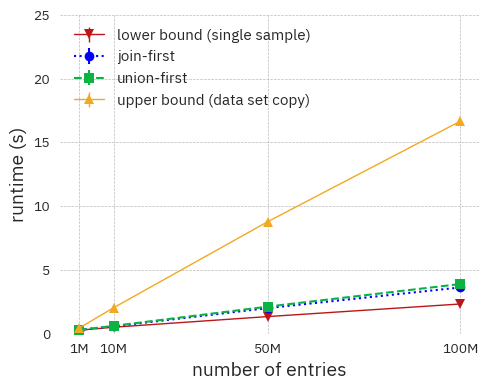

In [33]:
fig, ax = plt.subplots(figsize=(5,4))
# ax.set_xscale("log")
ax.set_xticks(df.index, labels=n_entries2numeric.keys())
ax.set_xlabel("number of entries")
ax.set_ylabel("runtime (s)")

linestyles = ["solid", "dashed", "dotted", "solid"]
markers = ["", "s", "^", ""]

ax.errorbar(df.index,
            df.walltime_mean["lower_bound"],
            yerr=df.walltime_std["lower_bound"],
            linestyle="solid",
            linewidth=1,
            marker="v",
            color="#BB1718"
           )

ax.errorbar(df.index,
            df.walltime_mean["join_first"],
            yerr=df.walltime_std["join_first"],
            linestyle="dotted",
            linewidth=1.5,
            marker="o",
            color="#0000FF"
           )

ax.errorbar(df.index,
            df.walltime_mean["union_first"],
            yerr=df.walltime_std["union_first"],
            linestyle="dashed",
            linewidth=1.5,
            marker="s",
            color="#0BB343"
           )

ax.errorbar(df.index,
            df.walltime_mean["upper_bound"],
            yerr=df.walltime_std["upper_bound"],
            linestyle="solid",
            linewidth=1,
            marker="^",
            color="#F2A922",
           )

ax.set_ylim([0, 25])
ax.legend(["lower bound (single sample)", "join-first", "union-first", "upper bound (data set copy)"], loc="upper left")

fig.tight_layout()
fig.savefig("plots/runtime_scenario2.pdf", transparent=True)
fig.savefig("/home/florine/cernbox/2025_ICT_OPEN/runtime_scenario2.png", transparent=True, dpi=1000)
fig.savefig("plots/runtime_scenario2.tex", format="pgf", transparent=True)